In [ ]:
import pickle as pkl
import experiments.utils_graph as utils_graph
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import pulsekit
rng = np.random.default_rng(42)

with open("data/fitted_graph_projgrad.pkl", "rb") as f:
    graph_projgrad = pkl.load(f)
with open("data/fitted_graph_projsubgrad.pkl", "rb") as f:
    graph_subgrad = pkl.load(f)
with open("data/fitted_graph_nonlinear.pkl", "rb") as f:
    graph_nonlinear = pkl.load(f)
with open("data/fitted_graph_neldermead.pkl", "rb") as f:
    graph_nelder = pkl.load(f)
with open("data/fitted_graph_phase.pkl", "rb") as f:
    graph_phase = pkl.load(f)
with open("data/fitted_graph_empirical.pkl", "rb") as f:
    graph_empirical = pkl.load(f)

In [ ]:
pairs = [(136, 306)]
times = []
reliabilities = []
paths = []
for (start, end) in pairs:
    sarp_model, time, init_path = utils_graph.run_sarp_bezier(graph_projgrad, start, end, 
                                                        alpha=0.9, gamma=0.4, n_sims=1_000, rng=rng)
    times.append(time)

    budget = sarp_model.parameters.constants['T_max']
    path = sarp_model.optimal_path
    distfit_check = utils_graph.path_cdf_distfit(graph_empirical, path, budget, n_sims=1_000, rng=rng)
    reliabilities.append(distfit_check)

    paths.append(path)

    print(f"Path from {start} to {end} with budget {budget}:")
    print(f"Optimal path: {path}")
    print(f"Montecarlo distfit reliability: {distfit_check}")

Path from 136 to 306 with budget 0.5381068323951741:
Optimal path: [136, 137, 512, 363, 480, 481, 258, 526, 176, 211, 164, 163, 309, 108, 109, 110, 323, 322, 306]
Montecarlo distfit reliability: 0.949


In [3]:
path = [int(p) for p in paths[0]]
# get path length
length =0
for i in range(len(path) - 1):
    length += graph_projgrad.nodes[path[i]].links[path[i + 1]].deterministic['length_miles']
print(f"Path length: {length} miles")

Path length: 9.98388966003847 miles


CDF at Time Budget: 0.9353138476795481


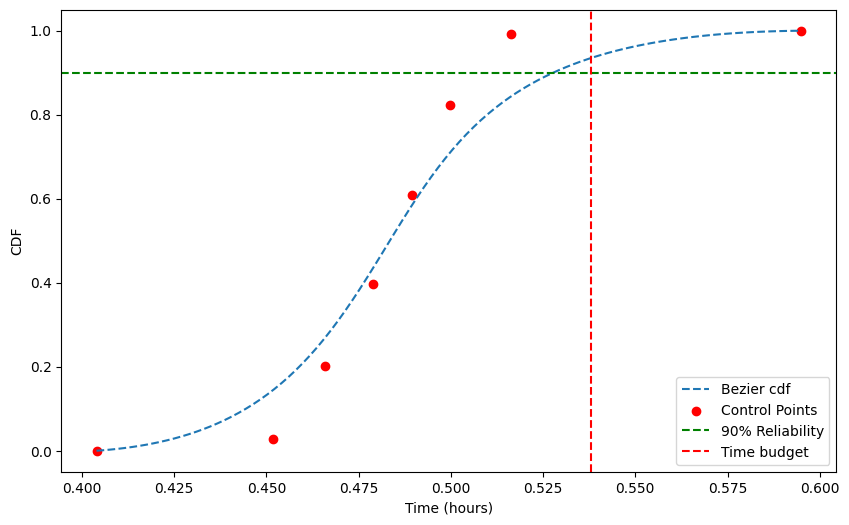

In [ ]:
bezierv = utils_graph.get_path_distribution(graph_projgrad, path, n_sims=500, rng=rng)
print(f"CDF at Time Budget: {bezierv.cdf_x(budget)}")
fig, ax = plt.subplots(figsize=(10, 6))
bezierv.plot_cdf(ax=ax)
# add hjorizontal line
ax.axhline(y=0.9, color='g', linestyle='--', label='90% Reliability')
# add vertical line at T_max
ax.axvline(x=budget, color='r', linestyle='--', label='Time budget')
# x axis
ax.set_xlabel('Time (hours)')
ax.set_ylabel('CDF')
plt.legend()
plt.show()

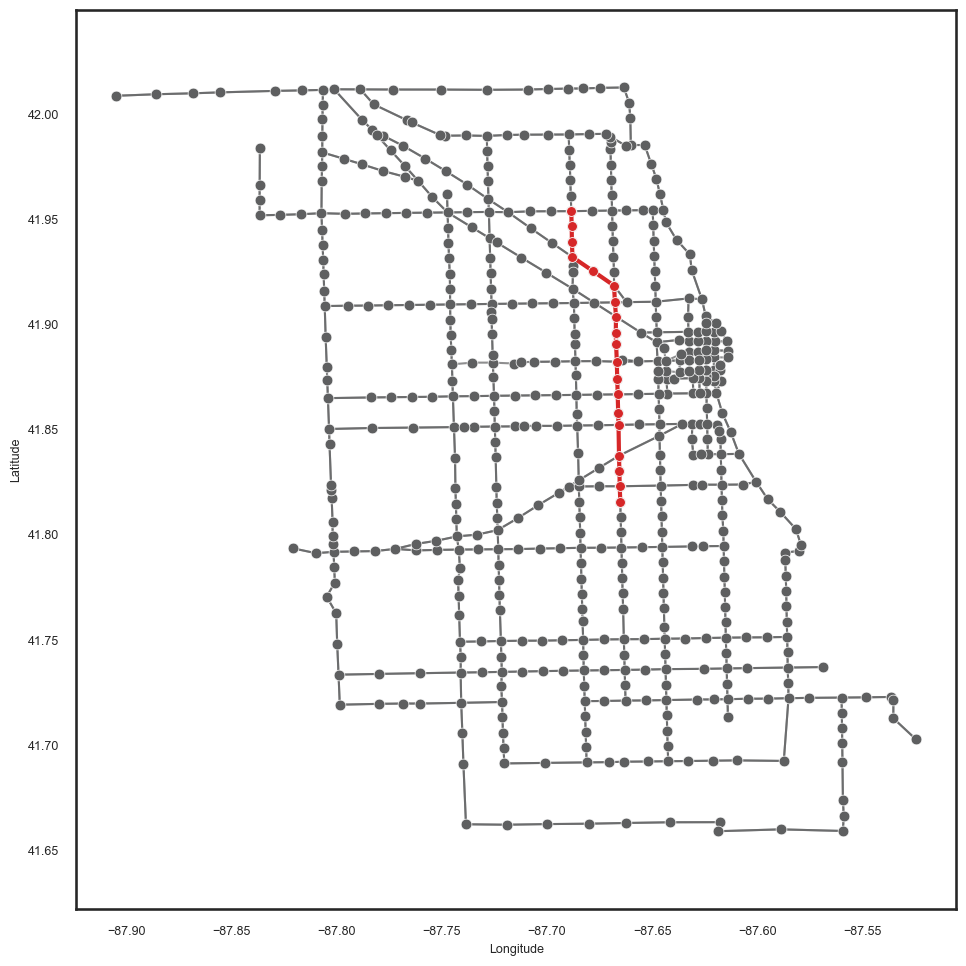

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# ──────────────────────────────────────────────────────────────────────────────
# Helper: extract one (lon, lat) pair for every node that appears in *any* link
# ──────────────────────────────────────────────────────────────────────────────
def _collect_positions(graph):
    """
    Build a dict {node_index: (x_lon, y_lat)} using all outgoing links.
    Fall-back: if a node only appears as a destination, we'll still capture it
    because we parse every Link's *end* coordinates as well.
    """
    pos = {}
    for u, node in graph.nodes.items():
        for v, link in node.links.items():
            d = link.deterministic
            # store both ends of the segment
            pos[u] = (d["start_longitude"], d["start_latitude"])
            pos[v] = (d["end_longitude"],   d["end_latitude"])
    return pos


# ──────────────────────────────────────────────────────────────────────────────
# Base plot: whole graph with optional node labels
# ──────────────────────────────────────────────────────────────────────────────
def plot_graph_sns(
    graph,
    annotate=False,
    edge_color=None,
    figsize=(8, 8),
):
    """
    Plot the entire network contained in a `graph.Graph` object.

    Parameters
    ----------
    graph : Graph
        Instance as defined in graph.py
    annotate : bool, default False
        Show node **names** next to the dots. (The name is `Node.name`.)
    edge_color : str/tuple, optional
        Colour for every edge; default = first colour in seaborn palette.
    figsize : tuple, default (8, 8)
        Matplotlib figure size.
    """
    positions = _collect_positions(graph)
    edges = [
        (u, v)
        for u, node in graph.nodes.items()
        for v in node.links.keys()
    ]

    if edge_color is None:
        edge_color = sns.color_palette("deep")[0]

    sns.set_theme(style="white", context="talk")
    fig, ax = plt.subplots(figsize=figsize)

    # Draw all edges
    lc = LineCollection(
        [[positions[u], positions[v]] for u, v in edges],
        colors=edge_color,
        linewidths=1.5,
        alpha=0.7,
    )
    ax.add_collection(lc)

    # Draw all nodes
    nodes_df = pd.DataFrame(
        [{"idx": idx, "name": graph.nodes[idx].name, "x": x, "y": y}
         for idx, (x, y) in positions.items()]
    )
    sns.scatterplot(
        data=nodes_df,
        x="x",
        y="y",
        s=60,
        color="#5E5F60",
        edgecolor="white",
        linewidth=0.5,
        alpha=1,
        ax=ax,
        zorder=3,
    )

    if annotate:
        for _, row in nodes_df.iterrows():
            ax.text(
                row.x,
                row.y,
                row.name,        # use the node *name* (more readable than idx)
                fontsize=6,
                ha="right",
                va="bottom",
            )

    ax.set_xlabel("Longitude", fontsize=9)
    ax.set_ylabel("Latitude", fontsize=9)
    ax.tick_params(axis="both", which="both", labelsize=9)
    ax.set_aspect("equal", adjustable="datalim")
    plt.tight_layout()
    return fig, ax


# ──────────────────────────────────────────────────────────────────────────────
# Overlay one path in red
# ──────────────────────────────────────────────────────────────────────────────
def plot_graph_with_path(
    graph,
    path,                       # sequence of node *indices* OR node *names*
    annotate=False,
    edge_color=None,
    path_color="#D62728",
    path_linewidth=3,
    figsize=(8, 8),
):
    """
    Wrapper that first calls `plot_graph_sns` and then highlights the path.

    Notes
    -----
    * `path` can be expressed either with the integer indices used by
      `graph.nodes` **or** with the human-friendly node names.
    * Mixing the two in the same list is allowed.
    """
    # If path is in names, convert to indices
    idx_path = [
        nid if isinstance(nid, int) else graph.name_to_index[nid]
        for nid in path
    ]

    fig, ax = plot_graph_sns(
        graph,
        annotate=annotate,
        edge_color=edge_color,
        figsize=figsize,
    )

    positions = _collect_positions(graph)
    path_edges = list(zip(idx_path[:-1], idx_path[1:]))

    # path edges
    lc_path = LineCollection(
        [[positions[u], positions[v]] for u, v in path_edges],
        colors=path_color,
        linewidths=path_linewidth,
        zorder=4,
    )
    ax.add_collection(lc_path)

    # path nodes
    xs, ys = zip(*(positions[i] for i in idx_path))
    sns.scatterplot(
        x=xs,
        y=ys,
        s=50,
        color=path_color,
        edgecolor="white",
        linewidth=0.6,
        zorder=5,
        ax=ax,
    )

    return fig, ax

#plot
fig, ax = plot_graph_with_path(
    graph_empirical,
    path,
    annotate=False,
    edge_color="#5E5F60",
    path_color="#D62728",
    figsize=(10, 10),
)

In [ ]:
n = 10
random_pairs = utils_graph.get_od_pairs(graph_empirical, n)
times = []
empirical_check = []

for (start, end) in tqdm.tqdm(random_pairs, desc="Running SARP on random pairs"):
    sarp_model, time, init_path = utils_graph.run_sarp_bezier(graph_projgrad, start, end, 
                                                        alpha=0.9, gamma=0.4, n_sims=100, rng=rng)
    times.append(time)
    budget = sarp_model.parameters.constants['T_max']
    path = sarp_model.optimal_path
    distfit_check = utils_graph.path_cdf_distfit(graph_empirical, path, budget, n_sims=100, rng=rng)
    empirical_check.append(distfit_check >= 0.9)

Running SARP on random pairs:   0%|          | 0/10 [00:00<?, ?it/s]

In [14]:
print(random_pairs)

[(495, 384), (241, 12), (273, 372), (463, 171), (241, 227), (64, 48), (428, 524), (444, 267), (501, 30), (486, 531)]


In [ ]:
for (start, end) in random_pairs:
    # get minimum cost path between start and end with preprocessing empirical
    

In [13]:
print(times)
print(empirical_check)
print(f"Average time: {np.mean(times):.2e} seconds")
print(f"Max time: {np.max(times):.2e} seconds")
print(f"Min time: {np.min(times):.2e} seconds")


[8.076390700000047, 85.36977769999794, 8.696592899999814, 13.534816899998987, 83.46524859999772, 0.005215999997744802, 377.3269619999992, 0.007152199999836739, 50.20029480000085, 1655.0093788000013]
[True, True, True, True, True, True, True, True, True, True]
Average time: 2.28e+02 seconds
Max time: 1.66e+03 seconds
Min time: 5.22e-03 seconds
